In [44]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

load_dotenv()

True

In [33]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0.7
)

In [34]:
result = llm.invoke("Who is the president of the United States?")
print(result)

content='I’m sorry, but I don’t have up‑to‑date information beyond my last training cut‑off in 2024. As of that time, Joe\u202fBiden was the U.S. president. For the current president in 2026, please check a reliable news source or official government website.' additional_kwargs={'reasoning_content': 'User asks: "Who is the president of the United States?" Likely wants current president. As of 2026? Actually current date is 2026-09-17. Who is president? As of 2024, Joe Biden was president until 2025? Actually Biden\'s term ended in 2025. The next election 2024. In 2024, the president would be whoever won. If it\'s 2026, it\'s likely the next president. We don\'t know. The user might be expecting knowledge cutoff? But knowledge cutoff is 2024-06. So as of 2024-06, Biden was still president. But we are in 2026. The assistant should not provide misinformation. The user is asking a factual question. The policy says we must not hallucinate. The assistant should either say "I don\'t know" or 

In [35]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages] #Reducer

In [39]:
def chat_node(state: ChatState):
    messages = state["messages"]
#send to llm
    response = llm.invoke(messages)
    return {"messages" : [response]}


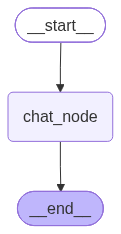

In [51]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()
chatbot

In [45]:
initial_state = {
    "messages": [HumanMessage(content="What is Agentic AI?")]
}

In [48]:
response = chatbot.invoke(initial_state)
response['messages'][-1].content

'## Agentic AI – A Quick Overview\n\n**Agentic AI** refers to artificial intelligence systems that are endowed with *agency*: the capacity to set goals, make decisions, take actions, and pursue those goals autonomously—often in dynamic, real‑world environments. In short, it’s AI that behaves like an *agent* in the sense of the classic “intelligent agent” paradigm in computer science and cognitive science.\n\n---\n\n### 1. Core Characteristics\n\n| Feature | What it means for Agentic AI |\n|---------|------------------------------|\n| **Autonomy** | The system can operate without continuous human instruction. |\n| **Goal‑orientation** | It has a defined objective (or set of objectives) that it seeks to achieve. |\n| **Decision‑making** | It evaluates alternatives, predicts outcomes, and chooses actions. |\n| **Learning & adaptation** | It refines its behavior based on experience or feedback. |\n| **Environment interaction** | It senses, perceives, and affects its surroundings. |\n| **Se

In [ ]:
while True:
    user_input = input("User: ")
    print('User:', user_input)
    if user_input.lower() in ["exit", "quit"]:
        print("Exiting the chatbot. Goodbye!")
        break
    response = chatbot.invoke('messages':[HumanMessage(content=user_input)])
    print('Chatbot:',response['messages'][-1].content)

SyntaxError: invalid syntax (2304060028.py, line 7)